In [37]:
from langgraph.graph import StateGraph, START, END
from langchain_openrouter import ChatOpenRouter
from typing import TypedDict
from dotenv import load_dotenv

In [38]:
load_dotenv()

True

In [39]:
model = ChatOpenRouter(model="openai/gpt-4o-mini")

In [40]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    evaluation_score: float

In [41]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f"Generate a detailed outline for the blog on the topic - {title}"
    outline = model.invoke(prompt).content

    state["outline"] = outline
    return state

In [42]:
def create_blog(state: BlogState) -> BlogState:

    title = state["title"]
    outline = state["outline"]

    prompt = f"Write a detailed blog on the tile - {title} using the following outline \n {outline}"
    content = model.invoke(prompt).content

    state["content"] = content
    return state

In [43]:
def evaluation(state: BlogState) -> BlogState:
    outline = state["outline"]
    content = state["content"]

    prompt = f"Evaluate the blog content given below based on the outline and provide score in the range of 0-10.\n outline - {outline} \n content: {content}"
    score = model.invoke(prompt)

    state["evaluation_score"] = score
    return state
    

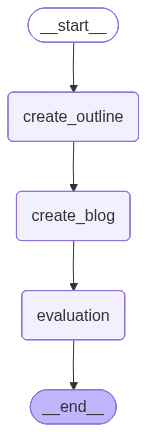

In [44]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_node("evaluation", evaluation)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog', "evaluation")
graph.add_edge('evaluation', END)

workflow = graph.compile()
workflow

In [45]:
initial_state = {"title": "AI Scenario of India and Its overall impact in future"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'AI Scenario of India and Its overall impact in future', 'outline': "# Blog Outline: AI Scenario of India and Its Overall Impact in the Future \n\n## Introduction\n- Brief introduction to Artificial Intelligence (AI) \n- Importance of AI in the global landscape \n- Focus on India’s unique position in the AI narrative \n- Purpose of the blog: To explore current AI scenarios in India and their future implications \n\n## 1. Current State of AI in India\n### 1.1 Government Initiatives\n  - Overview of national AI strategy \n  - Programs and policies supporting AI development (e.g., NITI Aayog’s AI Strategy)\n  - Investment in AI technologies by the government \n\n### 1.2 Private Sector Engagement\n  - Leading Indian companies in AI (e.g., Infosys, Wipro, Tata Consultancy Services)\n  - Startups and innovation hubs driving AI solutions \n  - Collaborations between startups and corporates \n\n### 1.3 Academic and Research Institutions\n  - Role of universities and institutes (e.g.,